### Feature Engineering

Here I derived the necessary features (useful information for prediction). 

Feature|Meaning
---|---
Elo rating|Team strength
Elo difference|Match advantage
Home advantage|Bias
Recent form|Momentum

#### Why Elo comes first

Right now the data treats teams equally i.e:
- Brazil = India ❌
- Germany = random team ❌

👉 No concept of strength

Elo fixes this learning team strength from match history”

This is:
- dynamic
- data-driven
- time-aware

## 1. What is Elo Rating? (Foundation concept)

Elo is a dynamic rating system that updates after every match. i.e “Teams gain points when they perform better than expected”

#### ⚽ Intuition
- If Brazil beats Germany → small increase (expected)
- If India beats Brazil → huge increase (unexpected)

This connects to:

Concept|In Elo
---|---
Probability|Expected win chance
Updating beliefs|Bayesian-style learning
Sequential data	|Time-dependent learning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
matches_df = pd.read_csv("../data/processed/matches_clean.csv")

# Update date column data type
matches_df['date'] = pd.to_datetime(matches_df['date'])

# Sort Valeus. Elo is sequential learning. future matches depend on past ratings.
matches_df = matches_df.sort_values("date").reset_index(drop=True)

In [3]:
# Initialize Elo Ratings
teams = pd.concat([matches_df['home_team'], matches_df['away_team']]).unique()

elo_ratings = {team:1500 for team in teams}

##### Idea

- 1500 = neutral starting skill
- Everyone starts equal
- Learns over time

## 📊 Elo Expected Score Formula

The Elo system estimates the probability that one team will beat another based on their ratings.

The formula:

$
E_A = \frac{1}{1 + 10^{\frac{R_B - R_A}{400}}}
$

---

### 🔍 What each term means

- $ E_A $: Expected probability that **Team A wins**
- $ R_A $: Rating of Team A  
- $ R_B $: Rating of Team B  

---

### 🧠 Intuition Behind the Formula

This formula converts **rating differences into probabilities**.

#### Case 1: Equal teams

If:
$ R_A = R_B $

Then:
$ E_A = \frac{1}{1 + 10^0} = \frac{1}{2} = 0.5 $

👉 Both teams have a **50% chance of winning**

---

#### Case 2: Team A is stronger

If:
$
R_A > R_B
$

Then:
- $ R_B - R_A $ is negative  
- The exponent becomes small  
- $ E_A $ becomes closer to **1**

👉 Team A is more likely to win

---

#### Case 3: Team A is weaker

If:
$
R_A < R_B
$

Then:
- $ R_B - R_A $ is positive  
- The exponent becomes large  
- $ E_A $ becomes closer to **0**

👉 Team A is less likely to win

---

### ⚙️ Why divide by 400?

The number **400** controls how sensitive the model is to rating differences.

- Small number → ratings have **big impact**
- Large number → ratings have **less impact**

👉 400 is a standard scaling factor used in Elo systems

---

### 🎯 Key Idea

> Elo turns **rating differences into probabilities** using a smooth curve (logistic-like function)

This is important because:
- Small rating gaps → close to 50/50
- Large gaps → strong favorite vs underdog

---

### 🔗 Connection to the Project

This expected probability:
- Drives how ratings update after each match
- Will later connect to the **Poisson goal model**

This essentially helps in learning **team strength from results over time**

In [4]:
# converts rating difference → probability
def expected_score(rating_a, rating_b):
    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))

# Updates elo rating
def update_elo(r_a, r_b, score_a, k=20):
    expected_a = expected_score(r_a, r_b)
    # New Rating = Old Rating + Learning Rate × (Actual - Expected)
    return r_a + k * (score_a - expected_a)


In [5]:
# Loop thro' matches

elo_home_list = []
elo_away_list = []
elo_history = []

for _, row in matches_df.iterrows():
    home = row['home_team']
    away = row['away_team']

    r_home=elo_ratings[home]
    r_away=elo_ratings[away]

    # Store current ratings pre-update
    elo_home_list.append(r_home)
    elo_away_list.append(r_away)

    # Match result
    if row["home_goals"] > row["away_goals"]:
        score_home=1
    elif row['home_goals'] < row["away_goals"]:
        score_home=0
    else:
        score_home=0.5

    elo_history.append({
        "date": row["date"],
        "team": home,
        "elo": r_home
    })

    elo_history.append({
        "date": row["date"],
        "team": away,
        "elo": r_away
    })

    # Update ratings
    new_home = update_elo(r_home, r_away,score_home)
    new_away = update_elo(r_away, r_home,1 - score_home)

    elo_ratings[home] = new_home
    elo_ratings[away] = new_away

# Add new Features to dataframe
matches_df['elo_home'] = elo_home_list
matches_df['elo_away'] = elo_away_list

matches_df["elo_diff"] = matches_df["elo_home"] - matches_df["elo_away"]

In [6]:
matches_df[["home_team", "away_team", "elo_home", "elo_away"]].head()

,home_team,away_team,elo_home,elo_away
0,Scotland,England,1500.000000,1500.000000
1,England,Scotland,1500.000000,1500.000000
2,Scotland,England,1490.000000,1510.000000
3,England,Scotland,1499.424989,1500.575011
4,Scotland,England,1500.541911,1499.458089


### Secondary Features Created
Feature|	Meaning
---|---
elo_home|	Strength of home team
elo_away|	Strength of away team
elo_diff|	Match advantage

In [7]:
# Visualize Top Teams
final_elo = pd.DataFrame(list(elo_ratings.items()), columns=['team', 'elo'])
final_elo.sort_values("elo", ascending=False).head(10)

,team,elo
35,Spain,1985.418413
8,Argentina,1985.258169
10,France,1953.160594
31,Brazil,1908.888723
1,England,1892.582129
49,Portugal,1891.140626
13,Netherlands,1879.235164
19,Germany,1878.354333
78,Colombia,1875.335931
32,Japan,1858.543684


<Axes: >

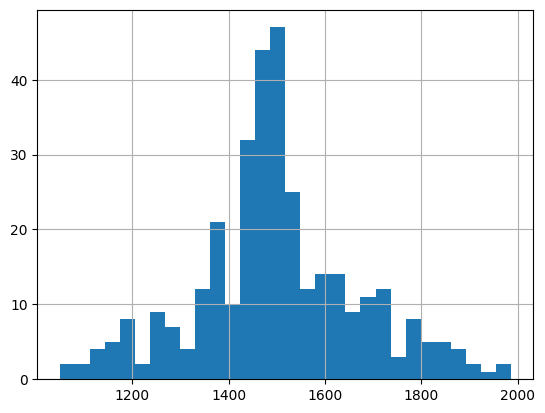

In [8]:
final_elo['elo'].hist(bins=30)

In [9]:
final_elo.to_csv("../data/processed/final_elo.csv", index=False)

In [10]:
elo_history = pd.DataFrame(elo_history)

print(f"Total Number of Teams in Dataset: {elo_history['team'].nunique()}")

Total Number of Teams in Dataset: 336


In [11]:
def plot_elo_evolution(df, country):
    team = df[df['team'] == country]

    plt.plot(team['date'], team['elo'])
    plt.title(f"{country}'s Elo Evolution over Time")
    plt.ylabel("Elo Rating")
    plt.xlabel("Year")
    plt.show()

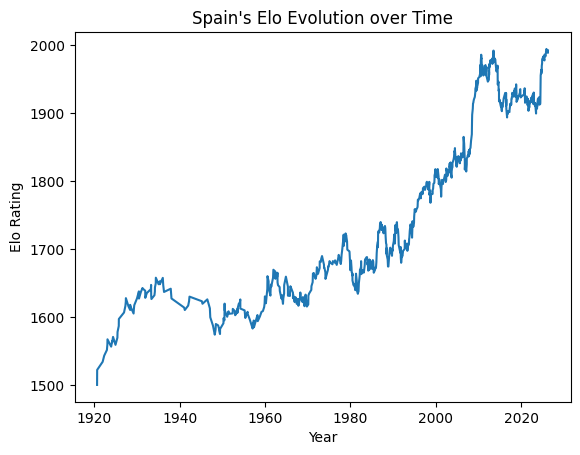

In [12]:
plot_elo_evolution(elo_history, "Spain")

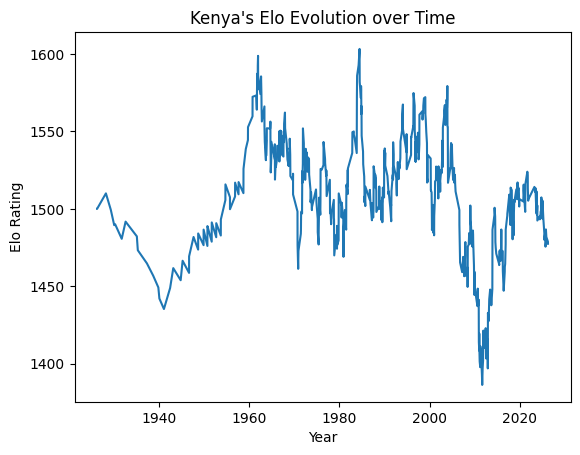

In [13]:
plot_elo_evolution(elo_history, "Kenya")

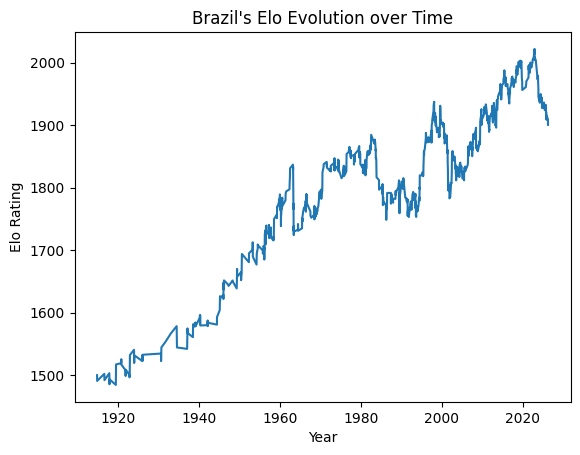

In [14]:
plot_elo_evolution(elo_history, "Brazil")

We now have:

✅ A time-aware model


✅ A team strength system


✅ A feature generator for ML

In [15]:
# EXPORT DATA FOR NEXT STEP
matches_df.to_csv("../data/processed/matches_with_features.csv", index=False)